# Bank Churn
### Tasks
1. Understand what churn is.
2. Exploratory Data Analysis.
3. Data preprocessing.
4. Feature Engineering.
5. Feature Selection.
6. Modelling and Evaluation.

## 1. What is Churn?

Churn is a measure of how many customers stop using a product. The main aim of a churn analysis is to predict whether a customer will stop using a product or service so that counter measures can be deployed to prevent the customer from leaving. The churn task is therefore a classification task to determine whether a client will exit or not.

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Exploratory Data Analysis
We are aiming to understand the data, what are the columns, their data types, relations with each other, missing or duplicate values

In [89]:
churn_data = pd.read_csv("./data.csv")

In [90]:
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [91]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [92]:
churn_data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [93]:
churn_data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [94]:
churn_data.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [95]:
duplicates = churn_data[churn_data.duplicated(subset=["RowNumber"])]
duplicates = churn_data[churn_data.duplicated(subset=["CustomerId"])]
duplicates = churn_data[churn_data.duplicated()]
duplicates

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [96]:
def numeric_univariate(column):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Description
    description = churn_data[column].describe(include="all")
    describe_df = pd.DataFrame(description)
    describe_df.columns = ["value"]
    print(describe_df)

    # Boxplot
    sns.boxplot(ax=axes[0], data=churn_data, x=column)
    axes[0].set_title(f"{column} (Boxplot)")

    # Distribution
    sns.kdeplot(ax=axes[1], data=churn_data, x=column, shade=True)
    axes[1].set_title(f"{column} (KDE)")
    plt.show()
    
    #Skewness
    print(f'{column}[Skewness]: {scipy.stats.skew(churn_data[column])}')
    print(f'{column}[Kurtosis]: {scipy.stats.kurtosis(churn_data[column])}')

             value
count  10000.00000
mean    5000.50000
std     2886.89568
min        1.00000
25%     2500.75000
50%     5000.50000
75%     7500.25000
max    10000.00000


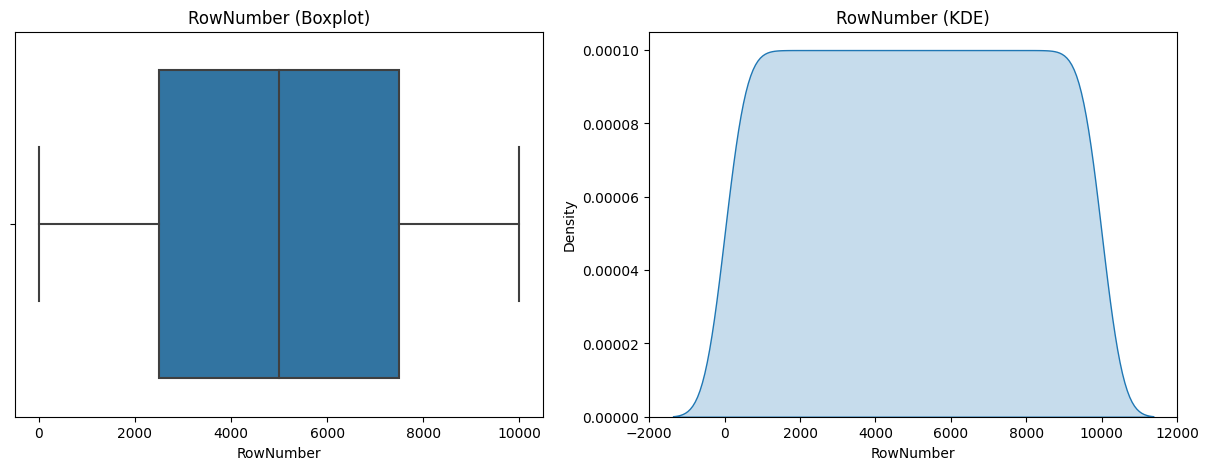

RowNumber[Skewness]: 0.0
RowNumber[Kurtosis]: -1.2000000240000006
              value
count  1.000000e+04
mean   1.569094e+07
std    7.193619e+04
min    1.556570e+07
25%    1.562853e+07
50%    1.569074e+07
75%    1.575323e+07
max    1.581569e+07


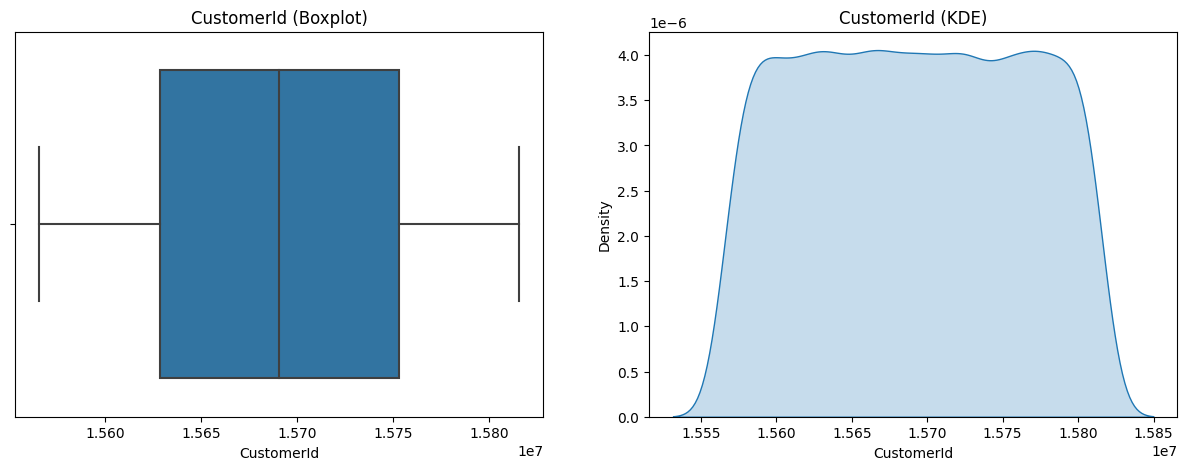

CustomerId[Skewness]: 0.001148973521486491
CustomerId[Kurtosis]: -1.1961144938712953
              value
count  10000.000000
mean     650.528800
std       96.653299
min      350.000000
25%      584.000000
50%      652.000000
75%      718.000000
max      850.000000


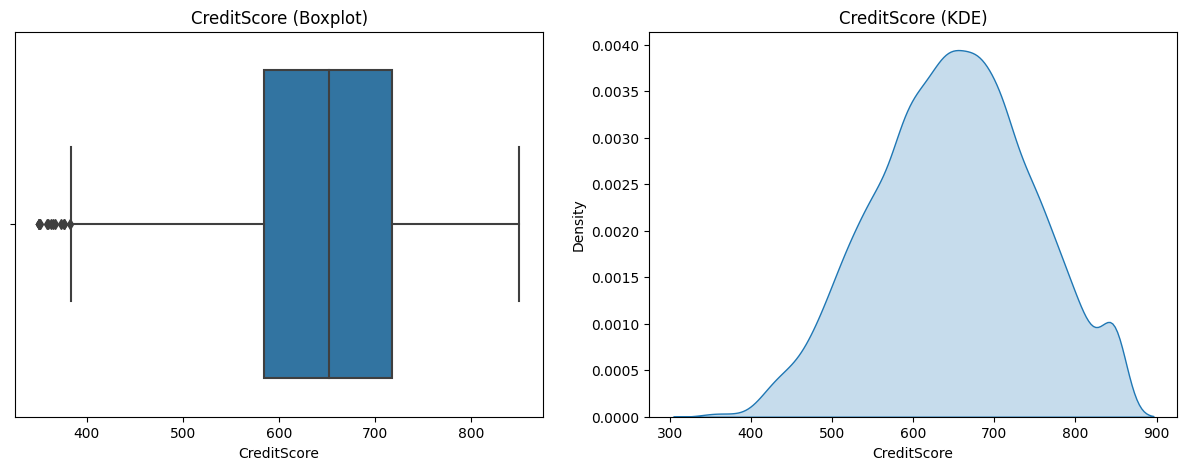

CreditScore[Skewness]: -0.07159586676212397
CreditScore[Kurtosis]: -0.42611279176518124
              value
count  10000.000000
mean      38.921800
std       10.487806
min       18.000000
25%       32.000000
50%       37.000000
75%       44.000000
max       92.000000


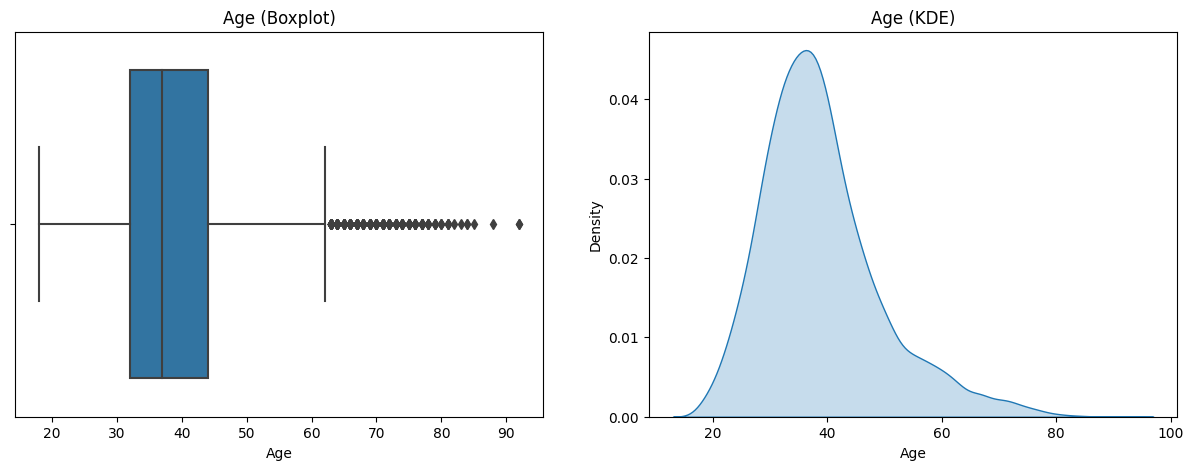

Age[Skewness]: 1.0111685586628079
Age[Kurtosis]: 1.3940495456392599
              value
count  10000.000000
mean       5.012800
std        2.892174
min        0.000000
25%        3.000000
50%        5.000000
75%        7.000000
max       10.000000


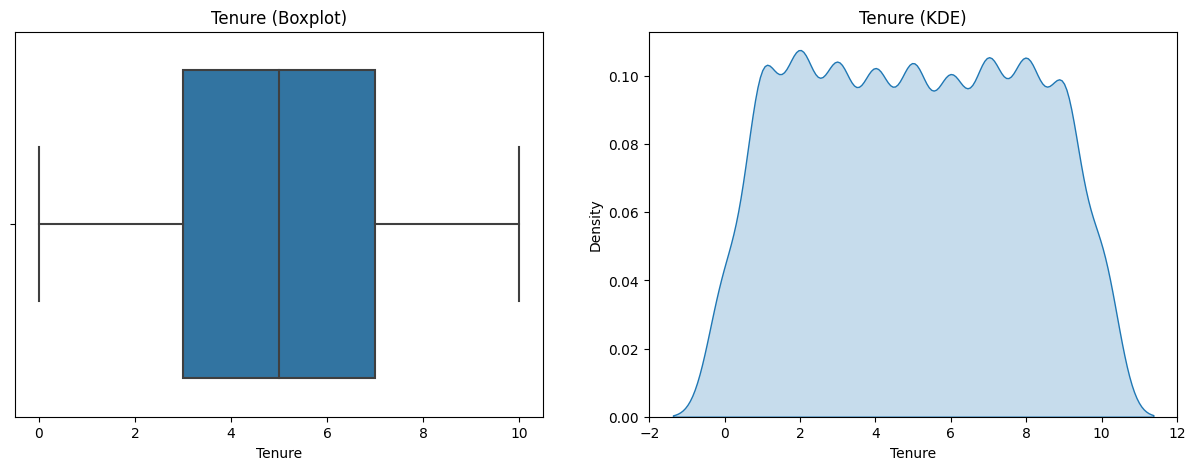

Tenure[Skewness]: 0.010989809189781041
Tenure[Kurtosis]: -1.1652426364413717
               value
count   10000.000000
mean    76485.889288
std     62397.405202
min         0.000000
25%         0.000000
50%     97198.540000
75%    127644.240000
max    250898.090000


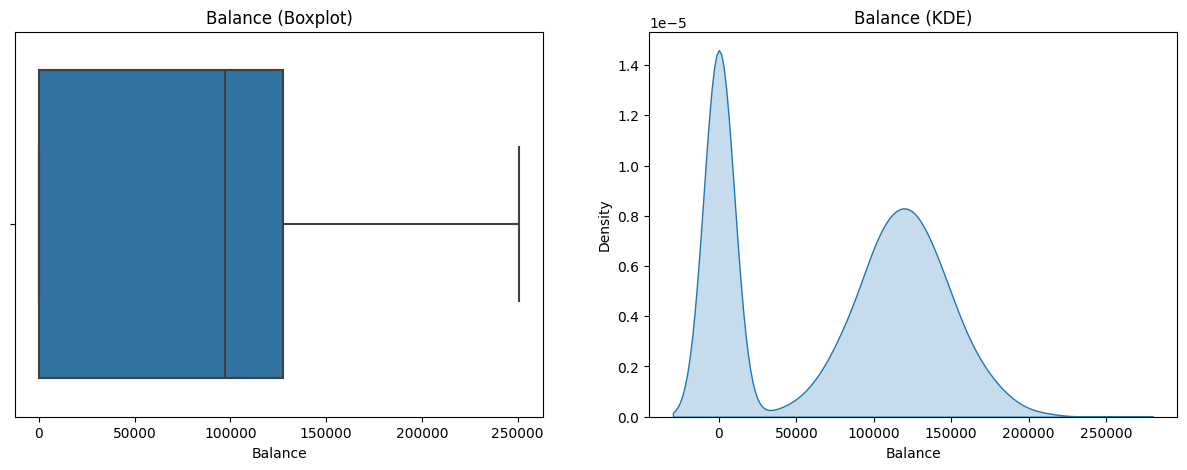

Balance[Skewness]: -0.14108754375291138
Balance[Kurtosis]: -1.489267106315331
              value
count  10000.000000
mean       1.530200
std        0.581654
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        4.000000


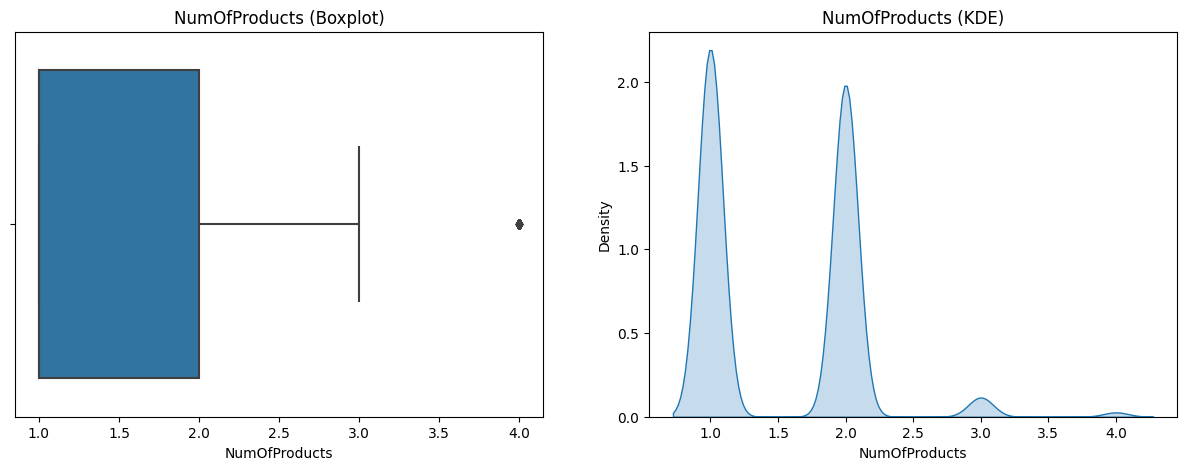

NumOfProducts[Skewness]: 0.745456048438949
NumOfProducts[Kurtosis]: 0.5820893733639854
             value
count  10000.00000
mean       0.70550
std        0.45584
min        0.00000
25%        0.00000
50%        1.00000
75%        1.00000
max        1.00000


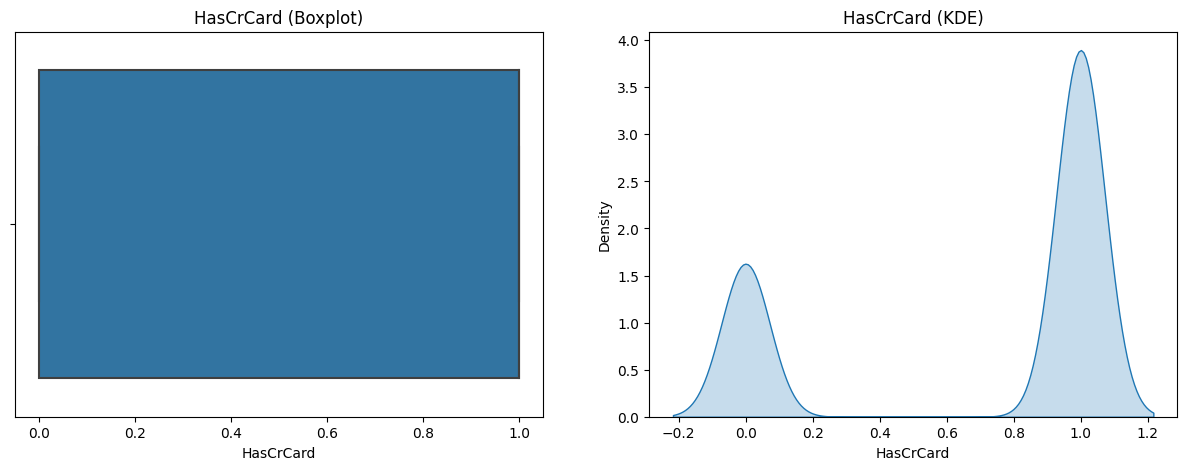

HasCrCard[Skewness]: -0.9016763178640548
HasCrCard[Kurtosis]: -1.18697981780312
              value
count  10000.000000
mean       0.515100
std        0.499797
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000


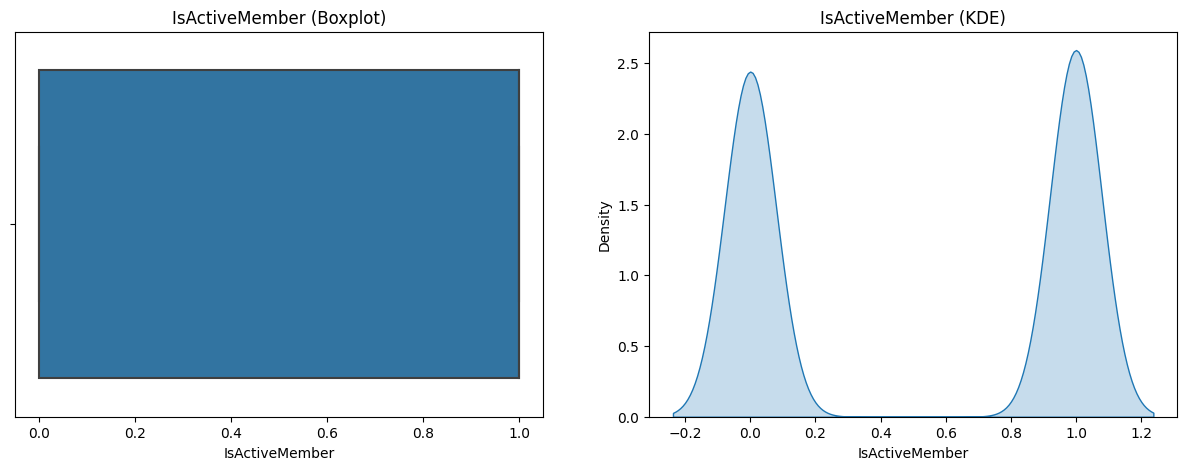

IsActiveMember[Skewness]: -0.06042756246298516
IsActiveMember[Kurtosis]: -1.996348509694782
               value
count   10000.000000
mean   100090.239881
std     57510.492818
min        11.580000
25%     51002.110000
50%    100193.915000
75%    149388.247500
max    199992.480000


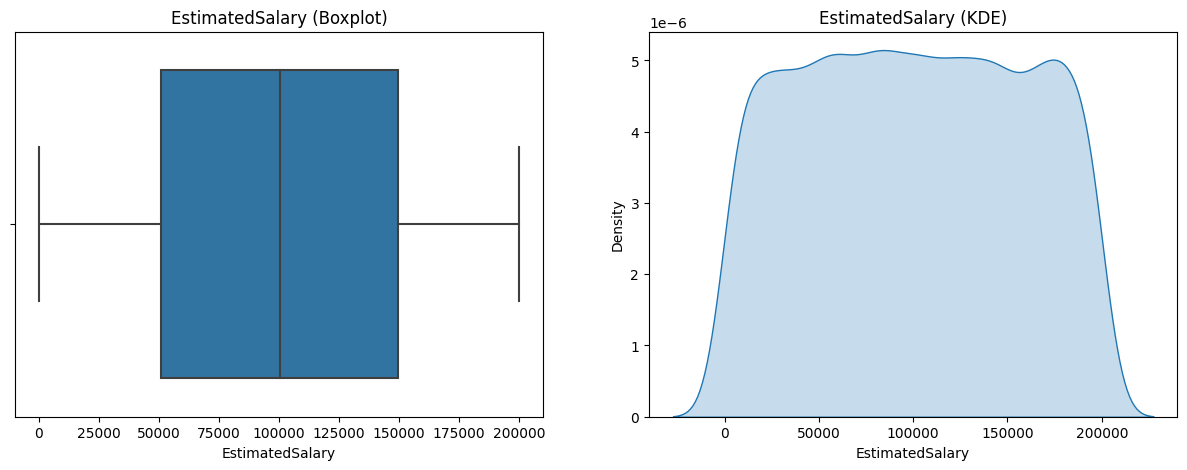

EstimatedSalary[Skewness]: 0.0020850448448748848
EstimatedSalary[Kurtosis]: -1.181527710874237
              value
count  10000.000000
mean       0.203700
std        0.402769
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000


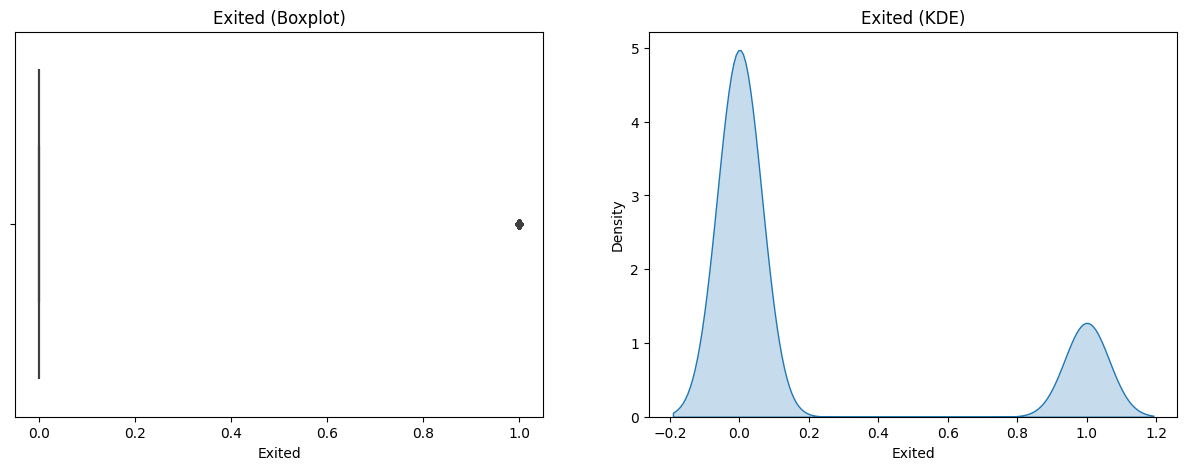

Exited[Skewness]: 1.4713899141398699
Exited[Kurtosis]: 0.16498827943253414


In [97]:
numerical_columns = [ col for col in churn_data.columns if churn_data[col].dtype != "object" ]
for col in numerical_columns:
    numeric_univariate(col)

In [98]:
def remove_outliers(col):
    const = 1.5
    iqr = scipy.stats.iqr(churn_data[col]) * const
    q1 = np.quantile(churn_data[col], 0.25)
    q3 = np.quantile(churn_data[col], 0.77)
    lower = q1 - iqr
    upper = q3 + iqr
    return lower,upper

<Axes: >

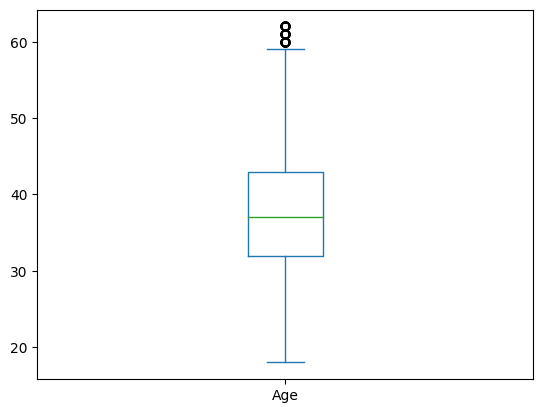

In [99]:
lower,upper = remove_outliers("Age")
churn_data = churn_data[(churn_data["Age"] < upper) & (churn_data["Age"] > lower)]
churn_data["Age"].plot(kind="box")

<Axes: >

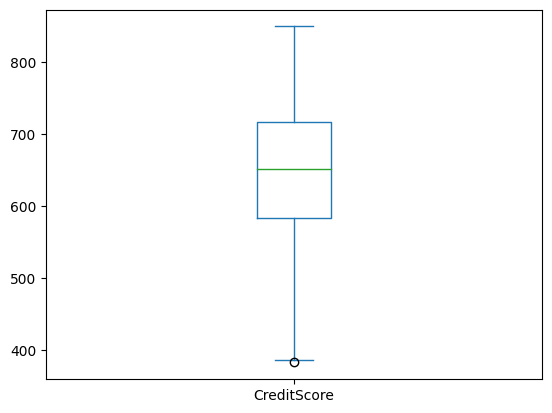

In [100]:
lower,upper = remove_outliers("CreditScore")
churn_data = churn_data[(churn_data["CreditScore"] < upper) & (churn_data["CreditScore"] > lower)]
churn_data["CreditScore"].plot(kind="box")

<Axes: >

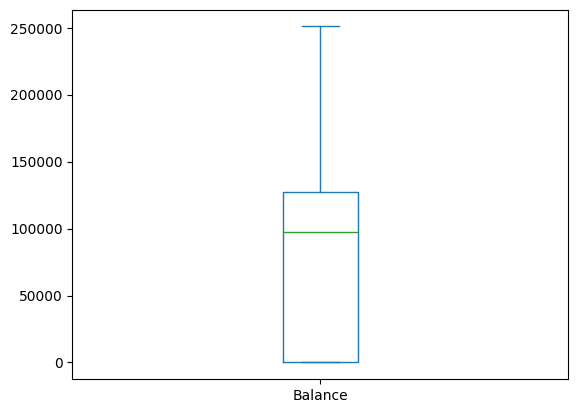

In [101]:
lower,upper = remove_outliers("Balance")
churn_data = churn_data[(churn_data["Balance"] < upper) & (churn_data["Balance"] > lower)]
churn_data["Balance"].plot(kind="box")

In [102]:
churn_data["Geography"].value_counts()

France     4826
Germany    2421
Spain      2379
Name: Geography, dtype: int64

In [103]:
churn_data["Gender"].value_counts()

Male      5258
Female    4368
Name: Gender, dtype: int64

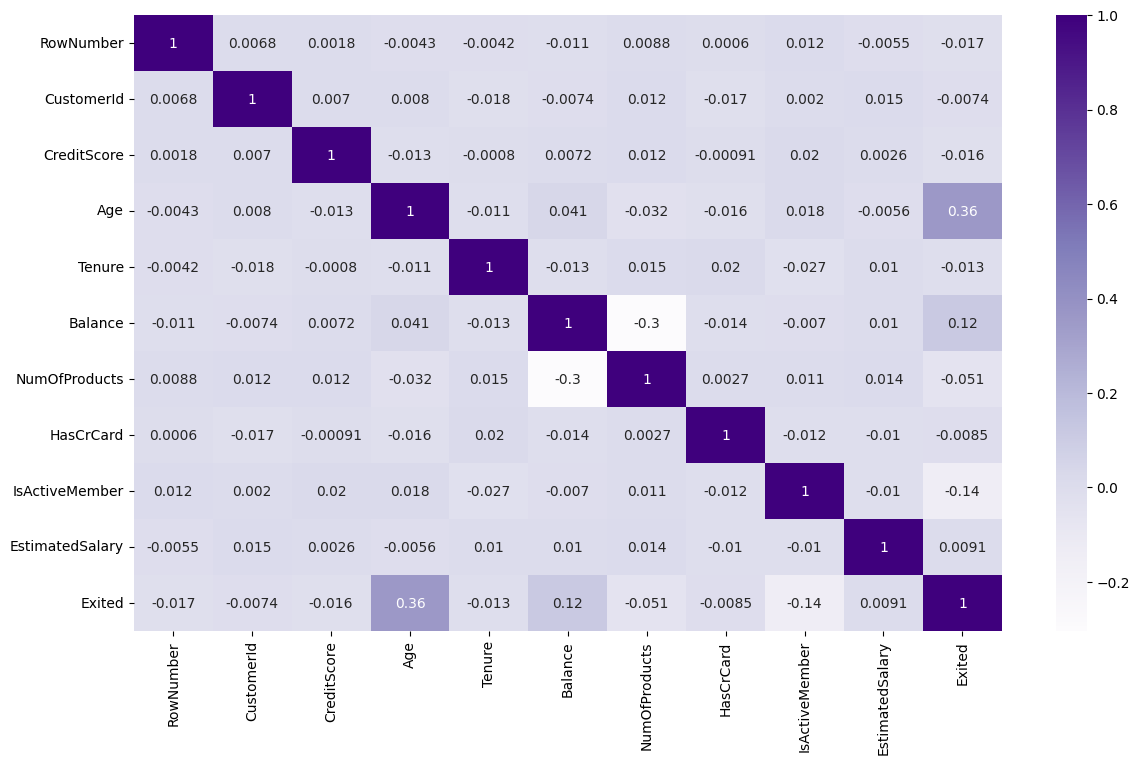

In [104]:
plt.figure(figsize=(14,8))
sns.heatmap(churn_data[numerical_columns].corr(),annot=True,cmap="Purples")
plt.show()

#### Summary
The `RowNumber`, `CustomerId` and `Surname` might represent noise in our data hence we will remove them. The `RowNumber` and `CustomerId` they might be used as keys to detect duplicates. There are no missing values/null and no duplicates.   The columns `HasCrCard`, `IsActiveMember` and `Exited` might be having the wrong data type. </br>
The following is a summary of the plot findings:
1. The age has outliners with some people in advanced ages
2. The credit score is also has outliers with a small bump in high credit score persons
3. The balance is skewed with a majority in the lower balance spectrum
4. The tenure is evenly distributed with multimodal chart due to most the integer setting of years of being a customer
5. Number of products is multimodal with some outlier clients with more that 2 products
6. Has credit card should be a boolean but it indicates here that there is a skewing towards clients without a credit card
7. IsActiveMember should also be boolean but it is balanced and multimodal
8. EstimatedSalary is evenly distributed with large kurtosis/spread
9. Exited is our target variable and idncicates some inbalance in our sampled data with most being in exited state. This is a YES/NO variable

## 3. Data Preprocessing, Feature Engineering and Feature Selection
- Remove outliers, nulls, duplicates - DONE
- Encode categorical features
- Drop unnecessary columns
- Train/Test split
- Bining continous features - Balance, Estimated Salary
- Scale features



#### Encode categorical features

In [105]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
churn_data.loc[:, 'Gender'] = le.fit_transform(churn_data.loc[:, 'Gender'])


In [106]:
from sklearn.preprocessing import OneHotEncoder
onehot = OneHotEncoder(sparse=False, drop='first', handle_unknown='error')

nominal = onehot.fit_transform(churn_data[['Geography']])
df_nominal = pd.DataFrame(index=churn_data.index, data=nominal, columns=onehot.get_feature_names_out(['Geography']))
churn_data = pd.concat([churn_data, df_nominal], axis=1)

### Drop unnecessary columns

In [107]:
# drop unnecessary columns
churn_data.drop(columns=['RowNumber', 'CustomerId', 'Surname','Geography'], inplace=True)
churn_data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0


In [108]:
churn_data.dtypes

CreditScore            int64
Gender                 int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Geography_Germany    float64
Geography_Spain      float64
dtype: object

#### Train/Test Split

In [109]:
from sklearn.model_selection import train_test_split

y_a = churn_data['Exited']
x_a = churn_data.drop(columns=['Exited'])
x_a_train, x_a_test, y_a_train, y_a_test = train_test_split(x_a, y_a, test_size=0.3, random_state=1, stratify=y_a)


#### Binning EstimatedSalary and Balance

In [110]:
x_a_train['Balance_Binned'] = pd.qcut(x_a_train.Balance, q=[0, .25, .50, .75, 1],duplicates='drop')
x_a_train['EstimatedSalary_Binned'] = pd.qcut(x_a_train.EstimatedSalary, q=[0, .25, .50, .75, 1],duplicates='drop')

x_a_train.drop(columns=['Balance', 'EstimatedSalary'], inplace=True)

x_a_train['Balance'] = le.fit_transform(x_a_train['Balance_Binned'])
x_a_train['EstimatedSalary'] = le.fit_transform(x_a_train['EstimatedSalary_Binned'])
x_a_train.drop(columns=['Balance_Binned', 'EstimatedSalary_Binned'], inplace=True)


# Test data
x_a_test['Balance_Binned'] = pd.qcut(x_a_test.Balance, q=[0, .25, .50, .75, 1],duplicates='drop')
x_a_test['EstimatedSalary_Binned'] = pd.qcut(x_a_test.EstimatedSalary, q=[0, .25, .50, .75, 1],duplicates='drop')

x_a_test.drop(columns=['Balance', 'EstimatedSalary'], inplace=True)

x_a_test['Balance'] = le.fit_transform(x_a_test['Balance_Binned'])
x_a_test['EstimatedSalary'] = le.fit_transform(x_a_test['EstimatedSalary_Binned'])

x_a_test.drop(columns=['Balance_Binned', 'EstimatedSalary_Binned'], inplace=True)



In [113]:
x_a_train.head()

,CreditScore,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,Geography_Germany,Geography_Spain,Balance,EstimatedSalary
7706,667,1,31,5,2,1,1,0.0,1.0,0,0
5034,631,0,29,2,2,1,1,1.0,0.0,0,0
710,540,1,48,0,1,0,0,0.0,0.0,2,2
5820,721,1,37,4,1,0,0,1.0,0.0,1,1
975,750,0,36,8,1,0,1,0.0,1.0,1,0


#### Scaling Data

In [128]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss_train = ss.fit_transform(x_a_train)
x_a_train_ss = pd.DataFrame(ss_train)
x_a_train_ss.columns=x_a_train.columns
x_a_train_ss.head()

#Test
ss_test = ss.fit_transform(x_a_test)
x_a_test_ss = pd.DataFrame(ss_test)
x_a_test_ss.columns=x_a_test.columns
x_a_test_ss.head()

,CreditScore,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,Geography_Germany,Geography_Spain,Balance,EstimatedSalary
0,-0.609692,-1.049711,-1.024256,-0.723995,-0.915018,0.638285,-1.012544,1.670337,-0.561354,1.507557,-0.447214
1,-2.060884,-1.049711,-1.138176,-0.723995,-0.915018,0.638285,-1.012544,1.670337,-0.561354,1.507557,0.447214
2,-0.959625,0.952644,2.165509,-1.770840,0.811025,-1.566699,0.987611,-0.598682,-0.561354,-0.904534,0.447214
3,1.119388,0.952644,0.114946,-1.072943,-0.915018,0.638285,0.987611,-0.598682,1.781407,-0.904534,-1.341641
4,-1.309558,-1.049711,0.570626,-0.723995,0.811025,0.638285,-1.012544,-0.598682,1.781407,-0.904534,-1.341641


### Modeling and Evaluation

In [130]:
#6. Apply algorithm 
# Models to be tested: L ogistic Regression, KNearest, SVM, Decision Tree, Random Forest, XGBoost, LightGBM

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [132]:
classifiers = {
    "LogisticRegression" : LogisticRegression(),
    "KNeighbors" : KNeighborsClassifier(),
    "SVC" : SVC(),
    "DecisionTree" : DecisionTreeClassifier(),
    "RandomForest" : RandomForestClassifier()
}

In [138]:
%%time
#Compute the training score of each models

train_scores = []
test_scores = []

for key, classifier in classifiers.items():
    classifier.fit(x_a_train_ss, y_a_train)
    train_score = round(classifier.score(x_a_train_ss, y_a_train),2)
    train_scores.append(train_score)
    test_score = round(classifier.score(x_a_test_ss, y_a_test),2)
    test_scores.append(test_score)

print(train_scores)
print(test_scores)

[0.83, 0.87, 0.87, 1.0, 1.0]
[0.82, 0.83, 0.85, 0.79, 0.86]
CPU times: user 4.27 s, sys: 168 ms, total: 4.44 s
Wall time: 4.24 s


In [140]:
train_cross_scores = []
test_cross_scores = []

for key, classifier in classifiers.items():
    classifier.fit(x_a_train_ss, y_a_train)
    train_score = cross_val_score(classifier, x_a_train_ss, y_a_train, cv=5)
    train_cross_scores.append(round(train_score.mean(),2))
    test_score = cross_val_score(classifier, x_a_test_ss, y_a_test, cv=5)
    test_cross_scores.append(round(test_score.mean(),2))
    
print(train_cross_scores)
print(test_cross_scores)

[0.83, 0.82, 0.86, 0.78, 0.86]
[0.82, 0.81, 0.85, 0.78, 0.85]


0.6889660828870556


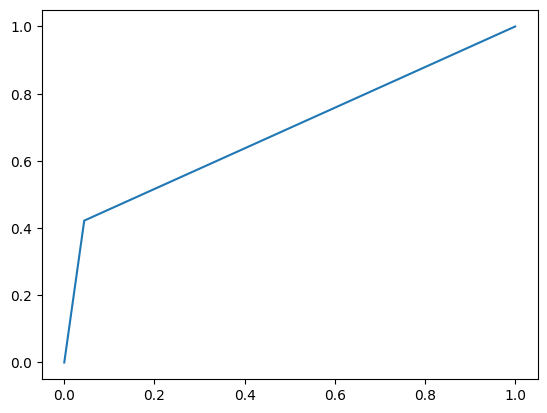

In [141]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

rf = RandomForestClassifier()
rf.fit(x_a_train, y_a_train)
rf_pred = cross_val_predict(rf, x_a_test, y_a_test, cv=5)
print(roc_auc_score(y_a_test, rf_pred))

fpr, tpr, _ = roc_curve(y_a_test, rf_pred)
plt.plot(fpr, tpr)
plt.show()